In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
import time
import requests
import json

# Test environment with Gymnasium

In [2]:
class SimpleTradingEnv(gym.Env):
    def __init__(self, df):
        super(SimpleTradingEnv, self).__init__()
        self.df = df
        self.reward_range = (-np.inf, np.inf)
        
        # Actions: 0 = Hold/Sell (Stay in Cash), 1 = Buy/Hold (Stay in Asset)
        self.action_space = spaces.Discrete(2)
        
        # Observation: Recent price changes (e.g., last 5 timestamps)
        self.observation_space = spaces.Box(low=-1, high=1, shape=(5,), dtype=np.float32)
        
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 5  # Start after the first 5 bars for observation
        self.balance = 1000.0  # Virtual starting money
        self.shares_held = 0
        return self._get_observation(), {}

    def _get_observation(self):
        # Return percentage change of the last 5 prices
        obs = self.df['Close'].pct_change().iloc[self.current_step-4:self.current_step+1].values
        return np.array(obs, dtype=np.float32)

    def step(self, action):
        current_price = self.df['Close'].iloc[self.current_step]
        
        # Execute "Pretend" Transaction
        if action == 1 and self.shares_held == 0: # Buy
            self.shares_held = self.balance / current_price
            self.balance = 0
        elif action == 0 and self.shares_held > 0: # Sell
            self.balance = self.shares_held * current_price
            self.shares_held = 0

        self.current_step += 1
        
        # Reward = Portfolio Value Change
        portfolio_value = self.balance + (self.shares_held * current_price)
        reward = portfolio_value - 1000.0 # Profit/Loss relative to start
        
        done = self.current_step >= len(self.df) - 1
        return self._get_observation(), reward, done, False, {}

In [18]:
data = pd.DataFrame({'Close': np.random.uniform(30000, 60000, size=100)})

data['Close'].pct_change().iloc[5-4:5+1].values

array([-0.12223551,  0.41553619,  0.30699711, -0.1096993 , -0.22018395])

In [19]:

# 2. Initialize and Train
env = Monitor(SimpleTradingEnv(data), "./logs/")
model = PPO("MlpPolicy", env, n_steps=2048, verbose=1)
model.learn(total_timesteps=5000)

# 3. Save the model
model.save("ppo_trading_agent_v1")

print("Training Complete. The agent has learned a pretend strategy!")

Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 94       |
|    ep_rew_mean     | 4.13e+04 |
| time/              |          |
|    fps             | 4317     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 94            |
|    ep_rew_mean          | 5.54e+04      |
| time/                   |               |
|    fps                  | 3437          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 2.0959502e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -0.693  

In [22]:
# Run inference on the training data to observe policy performance

# 1. Reset the environment to get the initial state (s0)
obs, info = env.reset()
done = False
results = {'reward': [], 'action': []}

# 2. Loop until the episode is finished (the end of your data)
while not done:
    # Use the model to predict the next action (a_t)
    # deterministic=True is crucial for inference; it uses the argmax of the policy
    action, _states = model.predict(obs, deterministic=True)
    
    # Apply the action to the environment
    obs, reward, terminated, truncated, info = env.step(action)
    
    done = terminated or truncated

    results['reward'].append(reward)
    results['action'].append(action)

# Convert data to DataFrame for analysis
results_df = pd.DataFrame(results)

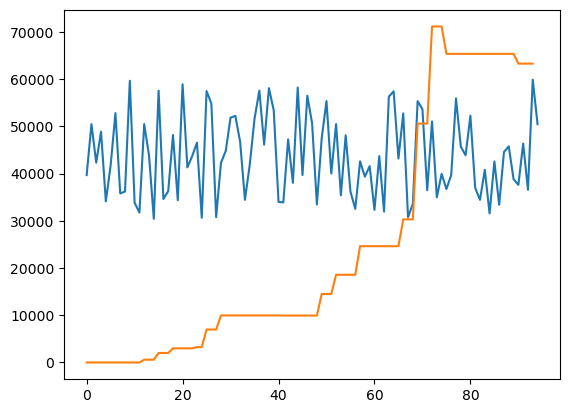

In [25]:
plt.plot(data['Close'][5:].values)
plt.plot(results_df['reward'])

# API helpers

In [ ]:
SLUG = 'btc-updown-5m-1771476300'  # Example slug for a BTC market on Polymarket
GAMMA_API = 'https://gamma-api.polymarket.com'
CLOB_API = 'https://clob.polymarket.com'

def get_token_ids_from_slug(slug):
    # Gamma API handles market discovery
    url = f"{GAMMA_API}/markets"
    response = requests.get(url, params={'slug': slug}).json()

    # clobTokenIds is a list: index 0 is YES, index 1 is NO
    token_ids = json.loads(response[0]['clobTokenIds'])
    return token_ids


def get_polymarket_book(token_id):
    """
    Fetches the live Order Book (Bids and Asks) for a specific token.
    """
    url = f"{CLOB_API}/book"
    params = {"token_id": token_id}
    
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        order_book = response.json()
        
        # print(f"--- Order Book for {token_id} ---")
        # print(f"Lowest Ask: {data['asks'][-1]['price']} (Size: {data['asks'][-1]['size']})")
        # print(f"Highest Bid: {data['bids'][-1]['price']} (Size: {data['bids'][-1]['size']})")
        
        return order_book
    
    except Exception as e:
        print(f"Error fetching data: {e}")
        return None
    

# TODO: execute both get_polymarket_book calls concurrently in ThreadPoolExecutor()
def get_btc_5m_polymarket_book_by_timestamp():
    # Calculate the current 5-minute interval timestamp
    # 300 seconds = 5 minutes
    current_time = int(time.time())
    current_interval = (current_time // 300) * 300
    slug = f"btc-updown-5m-{current_interval}"

    # Pass slug to get_token_ids_from_slug to retrieve the YES and NO token IDs
    yes_token_id, no_token_id = get_token_ids_from_slug(slug)

    # Fetch the Order Book for the 'Yes' token
    book_data_yes = get_polymarket_book(yes_token_id)
    book_data_no = get_polymarket_book(no_token_id)
    return book_data_yes, book_data_no


book_snapshot = get_btc_5m_polymarket_book_by_timestamp()

# Paper trading engine

In [322]:
class PaperAccount:
    def __init__(self, initial_usd):
        self.balance = initial_usd
        self.yes_shares = 0
        self.no_shares = 0
        self.pending_yes_orders = [] # List of {'price': 0.50, 'size': 100, 'side': 'BUY'|'SELL', 'order_type': 'GTC'|'GTD'|'FOK'|'FAK'}
        self.pending_no_orders = [] # List of {'price': 0.50, 'size': 100, 'side': 'BUY'|'SELL', 'order_type': 'GTC'|'GTD'|'FOK'|'FAK'}

    # TODO: Process all bids/asks in the order book, not just the best bid/ask
    # TODO: Account for partial fills and update pending orders accordingly
    # TODO: Implement market orders (FOK and FAK)
    # TODO: Implement post-only orders, merge and split.
    # TODO: Account for maker/taker fees and slippage
    # TODO: Account for minimum order sizes and market constraints
    # TODO: Account for "reserved" balance/shares that are locked in pending orders
    def sync_with_market(self, market_order_book, token_type='YES'):
        if token_type == 'YES':
            pending_orders = self.pending_yes_orders
        else:
            pending_orders = self.pending_no_orders

        for order in pending_orders:
            if order['side'] == 'BUY':
                self._execute_buy(market_order_book, order, token_type)

            elif order['side'] == 'SELL':
                self._execute_sell(market_order_book, order, token_type)


    def _execute_buy(self, market_order_book, order, token_type):
        pending_orders = self.pending_yes_orders if token_type == 'YES' else self.pending_no_orders
        remaining_size = order['size']
        cost = 0
        for level in reversed(market_order_book['asks']):  # Start from the lowest ask
            level_price, level_size = float(level['price']), float(level['size'])
            # Check if current ask is at or below the order price
            if level_price <= order['price']:
                trade_size = min(level_size, remaining_size)
                cost += trade_size * level_price # Update cost based on the actual trade size and price
                remaining_size -= trade_size # Update remaining size after the trade
                # Check if we have enough balance to cover the cost of this trade
                if cost >= self.balance:
                    print(f"Insufficient balance to fill order [BUY]: {order['size']} @ {level['price']}")
                    pending_orders.remove(order)
                    return
                # Check if the order is fully filled
                if remaining_size <= 0:
                    print(f"Order filled [BUY]: {order['size']} @ {level['price']}")
                    self.balance -= cost
                    pending_orders.remove(order)
                    break
    
            # If we reach a price level above the order price, we need to check the order type for partial fills
            else:
                if order['order_type'] == 'FOK':
                    print(f"FOK order cannot be filled [BUY]: {order['size']} @ {order['price']}")
                    pending_orders.remove(order)
                    return
                elif order['order_type'] == 'FAK':
                    print(f"FAK order partially filled [BUY]: {remaining_size} @ {level['price']}")
                    self.balance -= cost
                    pending_orders.remove(order)
                else:
                    print(f"Limit order filled partially [BUY]: {order['size'] - remaining_size} @ {level['price']}")
                    self.balance -= cost
                break
        # Update shares held based on the filled size
        new_shares = order['size'] - remaining_size
        order['size'] = remaining_size  # Update the order size to reflect the remaining unfilled portion (if it's a limit order)
        if token_type == 'YES':
            self.yes_shares += new_shares
        else:
            self.no_shares += new_shares
        

    def _execute_sell(self, market_order_book, order, token_type):
        if token_type == 'YES':
            shares = self.yes_shares
        else:
            shares = self.no_shares
        # Check if we have enough shares to sell
        if shares < order['size']:
            print(f"Insufficient shares to fill order [SELL]: {order['size']} @ {order['price']}")
            return
        
        pending_orders = self.pending_yes_orders if token_type == 'YES' else self.pending_no_orders
        remaining_size = order['size']
        profit = 0
        for level in reversed(market_order_book['bids']):  # Start from the highest bid
            level_price, level_size = float(level['price']), float(level['size'])
            # Check if current bid is at or above the order price
            if level_price >= order['price']:
                trade_size = min(level_size, remaining_size)
                profit += trade_size * level_price  # Update profit based on the actual trade size and price
                remaining_size -= trade_size        # Update remaining size after the trade
                # Check if the order is fully filled                
                if remaining_size <= 0:
                    print(f"Order filled [SELL]: {order['size']} @ {level['price']}")
                    self.balance += profit
                    pending_orders.remove(order)
                    break
            
            # If we reach a price level below the order price, we need to check the order type for partial fills
            else:
                if order['order_type'] == 'FOK':
                    print(f"FOK order cannot be filled [SELL]: {order['size']} @ {order['price']}")
                    pending_orders.remove(order)
                    return
                elif order['order_type'] == 'FAK':
                    print(f"FAK order partially filled [SELL]: {remaining_size} @ {level['price']}")
                    self.balance += profit
                    pending_orders.remove(order)
                else:
                    print(f"Limit order filled partially [SELL]: {order['size'] - remaining_size} @ {level['price']}")
                    self.balance += profit
                break

        sold_shares = order['size'] - remaining_size
        order['size'] = remaining_size  # Update the order size to reflect the remaining unfilled portion (if it's a limit order)
        if token_type == 'YES':
            self.yes_shares -= sold_shares
        else:
            self.no_shares -= sold_shares

# Demo

In [328]:
# ---- DEMO ---- #
INIT_BALANCE = 50
account = PaperAccount(initial_usd=INIT_BALANCE)
book_yes, book_no = get_btc_5m_polymarket_book_by_timestamp()
init_interval = (int(book_yes['timestamp']) // 1000) // 300 * 300
while True:
    if int(time.time() // 300) * 300 != init_interval:
        print("Market has closed. Exiting demo.")
        break

    # Simple trading logic:
    if book_yes and len(account.pending_yes_orders) < 5:
        if book_yes['asks'] and float(book_yes['asks'][-1]['price']) > 0.5 and account.balance > 0:
            account.pending_yes_orders.append(
                {'price': float(book_yes['asks'][-1]['price']), 'size': 10, 'side': 'BUY', 'order_type': 'FAK'}
            )
        elif book_yes['bids'] and account.yes_shares > 0:
            account.pending_yes_orders.append({'price': float(book_yes['bids'][-1]['price']), 'size': min(10, account.yes_shares), 'side': 'SELL', 'order_type': 'FAK'})

    if book_no and len(account.pending_no_orders) < 5:
        if book_no['asks'] and float(book_no['asks'][-1]['price']) > 0.5 and account.balance > 0:
            account.pending_no_orders.append({'price': float(book_no['asks'][-1]['price']), 'size': 10, 'side': 'BUY', 'order_type': 'FAK'})
        elif book_no['bids'] and account.no_shares > 0:
            account.pending_no_orders.append({'price': float(book_no['bids'][-1]['price']), 'size': min(10, account.no_shares), 'side': 'SELL', 'order_type': 'FAK'})

    # Small delay to simulate network latency
    time.sleep(0.2)

    # Get order books for both YES and NO shares
    book_yes, book_no = get_btc_5m_polymarket_book_by_timestamp()
    if book_yes and len(book_yes['asks']) > 0 and len(book_yes['bids']) > 0:
        print(f"Timestamp: {(int(book_yes['timestamp']) // 1000) - init_interval}sec, last trade price: {book_yes['last_trade_price']}, \
            spread: {float(book_yes['asks'][-1]['price']) - float(book_yes['bids'][-1]['price'])}")
        account.sync_with_market(book_yes, token_type='YES')  # Sync with YES token book

    if book_no and len(book_no['asks']) > 0 and len(book_no['bids']) > 0:
        account.sync_with_market(book_no, token_type='NO')   # Sync with NO token book
    
    print(f"PnL: {account.balance - INIT_BALANCE}, Current Balance: {account.balance}, Yes Shares Held: {account.yes_shares}, No Shares Held: {account.no_shares}")


# Get final market resolution
res = requests.get(f'{GAMMA_API}/markets', params={'slug': f'btc-updown-5m-{init_interval}'}).json()
outcome_prices = json.loads(res[0]['outcomePrices'])
final_bal = account.balance + (account.yes_shares if float(outcome_prices[0]) > 0.5 else account.no_shares)
pnl = final_bal - INIT_BALANCE
print(f"Final PnL: {pnl}, Final Balance: {final_bal}, Yes Shares Held: {account.yes_shares}, No Shares Held: {account.no_shares}")

Timestamp: 120sec, last trade price: 0.250,             spread: 0.010000000000000009
Order filled [BUY]: 10 @ 0.76
PnL: -7.600000000000001, Current Balance: 42.4, Yes Shares Held: 0, No Shares Held: 10
Timestamp: 121sec, last trade price: 0.250,             spread: 0.010000000000000009
Order filled [BUY]: 10 @ 0.76
PnL: -15.200000000000003, Current Balance: 34.8, Yes Shares Held: 0, No Shares Held: 20
Timestamp: 121sec, last trade price: 0.760,             spread: 0.010000000000000009
Order filled [BUY]: 10 @ 0.76
PnL: -22.800000000000004, Current Balance: 27.199999999999996, Yes Shares Held: 0, No Shares Held: 30
Timestamp: 122sec, last trade price: 0.760,             spread: 0.010000000000000009
Order filled [BUY]: 10 @ 0.76
PnL: -30.400000000000006, Current Balance: 19.599999999999994, Yes Shares Held: 0, No Shares Held: 40
Timestamp: 122sec, last trade price: 0.760,             spread: 0.010000000000000009
Order filled [BUY]: 10 @ 0.76
PnL: -38.00000000000001, Current Balance: 11.9

In [351]:
res = requests.get(f'{GAMMA_API}/markets', params={'slug': f'btc-updown-5m-{init_interval}'}).json()

In [ ]:
{'id': '1511832', 'question': 'Bitcoin Up or Down - March 6, 7:30PM-7:45PM ET', 'market': '0xb4d6e8b79603b8f6165e977f80afded9e85ac6193094ba9dc6b74338de9496e5', 'slug': 'btc-updown-15m-1772843400', 'description': 'This market will resolve to "Up" if the Bitcoin price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the BTC/USD data stream available at https://data.chain.link/streams/btc-usd.\nPlease note that this market is about the price according to Chainlink data stream BTC/USD, not according to other sources or spot markets.', 'assets_ids': ['54934848587189726173610058568096539857183993399971304860321273971533419829512', '24105284701240506783304732034455248846043203070635599469765924832981287835897'], 'outcomes': ['Up', 'Down'], 'event_message': {'id': '248844', 'ticker': 'btc-updown-15m-1772843400', 'slug': 'btc-updown-15m-1772843400', 'title': 'Bitcoin Up or Down - March 6, 7:30PM-7:45PM ET', 'description': 'This market will resolve to "Up" if the Bitcoin price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the BTC/USD data stream available at https://data.chain.link/streams/btc-usd.\nPlease note that this market is about the price according to Chainlink data stream BTC/USD, not according to other sources or spot markets.'}, 'timestamp': '1772757517429', 'event_type': 'new_market', 'tags': []}
{'id': '1511834', 'question': 'XRP Up or Down - March 6, 7:30PM-7:35PM ET', 'market': '0x88d1d3f0e068222346520f794af382268b7ca7b296172d2d25a396e874cd724b', 'slug': 'xrp-updown-5m-1772843400', 'description': 'This market will resolve to "Up" if the XRP price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the XRP/USD data stream available at https://data.chain.link/streams/xrp-usd.\nPlease note that this market is about the price according to Chainlink data stream XRP/USD, not according to other sources or spot markets.', 'assets_ids': ['109819492398851515967013728897697958606771570649033548819553242926367812729497', '52956334044033773006653512671306515794458790160399118086815547998701750732904'], 'outcomes': ['Up', 'Down'], 'event_message': {'id': '248846', 'ticker': 'xrp-updown-5m-1772843400', 'slug': 'xrp-updown-5m-1772843400', 'title': 'XRP Up or Down - March 6, 7:30PM-7:35PM ET', 'description': 'This market will resolve to "Up" if the XRP price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the XRP/USD data stream available at https://data.chain.link/streams/xrp-usd.\nPlease note that this market is about the price according to Chainlink data stream XRP/USD, not according to other sources or spot markets.'}, 'timestamp': '1772757517687', 'event_type': 'new_market', 'tags': []}
{'id': '1511833', 'question': 'Ethereum Up or Down - March 6, 7:30PM-7:45PM ET', 'market': '0x37d3fa6a94461e88f288f5f3e920f41b79728efdd935f250d7cd601ca6aeebfc', 'slug': 'eth-updown-15m-1772843400', 'description': 'This market will resolve to "Up" if the Ethereum price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the ETH/USD data stream available at https://data.chain.link/streams/eth-usd.\nPlease note that this market is about the price according to Chainlink data stream ETH/USD, not according to other sources or spot markets.', 'assets_ids': ['108272930925502552921007056786231411995555270612344601581953307279932477356685', '418270198563163704802855007416229212712057141970288625618928507051307420392'], 'outcomes': ['Up', 'Down'], 'event_message': {'id': '248845', 'ticker': 'eth-updown-15m-1772843400', 'slug': 'eth-updown-15m-1772843400', 'title': 'Ethereum Up or Down - March 6, 7:30PM-7:45PM ET', 'description': 'This market will resolve to "Up" if the Ethereum price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the ETH/USD data stream available at https://data.chain.link/streams/eth-usd.\nPlease note that this market is about the price according to Chainlink data stream ETH/USD, not according to other sources or spot markets.'}, 'timestamp': '1772757519311', 'event_type': 'new_market', 'tags': []}
{'id': '1511835', 'question': 'Ethereum Up or Down - March 6, 7:30PM-7:35PM ET', 'market': '0xc89d800dceda388fb97985b0dc7e9376b38a3f1494856f9c6e68258376fd6bb8', 'slug': 'eth-updown-5m-1772843400', 'description': 'This market will resolve to "Up" if the Ethereum price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the ETH/USD data stream available at https://data.chain.link/streams/eth-usd.\nPlease note that this market is about the price according to Chainlink data stream ETH/USD, not according to other sources or spot markets.', 'assets_ids': ['76363234165623203009264025929220117534176488571600475009441331470872730653618', '69105754124084355515571079105345545624727295858581678574895559900694941497467'], 'outcomes': ['Up', 'Down'], 'event_message': {'id': '248847', 'ticker': 'eth-updown-5m-1772843400', 'slug': 'eth-updown-5m-1772843400', 'title': 'Ethereum Up or Down - March 6, 7:30PM-7:35PM ET', 'description': 'This market will resolve to "Up" if the Ethereum price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the ETH/USD data stream available at https://data.chain.link/streams/eth-usd.\nPlease note that this market is about the price according to Chainlink data stream ETH/USD, not according to other sources or spot markets.'}, 'timestamp': '1772757519565', 'event_type': 'new_market', 'tags': []}
{'id': '1511836', 'question': 'Bitcoin Up or Down - March 6, 7:30PM-7:35PM ET', 'market': '0xb1c0e790f07e7cf177c198360b1847b745fe20cb70167ef9fa95657c34fa6c4f', 'slug': 'btc-updown-5m-1772843400', 'description': 'This market will resolve to "Up" if the Bitcoin price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the BTC/USD data stream available at https://data.chain.link/streams/btc-usd.\nPlease note that this market is about the price according to Chainlink data stream BTC/USD, not according to other sources or spot markets.', 'assets_ids': ['81333482583210031265504979140942448278855347434468737216034456623038460166515', '50290959671309915214902115230177006084974475718801870686446619344069101988671'], 'outcomes': ['Up', 'Down'], 'event_message': {'id': '248848', 'ticker': 'btc-updown-5m-1772843400', 'slug': 'btc-updown-5m-1772843400', 'title': 'Bitcoin Up or Down - March 6, 7:30PM-7:35PM ET', 'description': 'This market will resolve to "Up" if the Bitcoin price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the BTC/USD data stream available at https://data.chain.link/streams/btc-usd.\nPlease note that this market is about the price according to Chainlink data stream BTC/USD, not according to other sources or spot markets.'}, 'timestamp': '1772757519821', 'event_type': 'new_market', 'tags': []}
{'id': '1511831', 'question': 'XRP Up or Down - March 6, 7:30PM-7:45PM ET', 'market': '0x4b1427c90dcfa272dda2d480bc656dbf082e36a6ce7bbba05394a4c14303e1fa', 'slug': 'xrp-updown-15m-1772843400', 'description': 'This market will resolve to "Up" if the XRP price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the XRP/USD data stream available at https://data.chain.link/streams/xrp-usd.\nPlease note that this market is about the price according to Chainlink data stream XRP/USD, not according to other sources or spot markets.', 'assets_ids': ['75468879473847170307287706561342705507304995192118731874484771328211341305058', '49383257504705612123946088293977526993692705378096797302768351560474649484659'], 'outcomes': ['Up', 'Down'], 'event_message': {'id': '248843', 'ticker': 'xrp-updown-15m-1772843400', 'slug': 'xrp-updown-15m-1772843400', 'title': 'XRP Up or Down - March 6, 7:30PM-7:45PM ET', 'description': 'This market will resolve to "Up" if the XRP price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the XRP/USD data stream available at https://data.chain.link/streams/xrp-usd.\nPlease note that this market is about the price according to Chainlink data stream XRP/USD, not according to other sources or spot markets.'}, 'timestamp': '1772757523347', 'event_type': 'new_market', 'tags': []}
{'id': '1511837', 'question': 'Solana Up or Down - March 6, 7:30PM-7:45PM ET', 'market': '0xf975fe87afbbd33c223088b7fc07f8f1cdc3b64241a7e9a04eb83826e20ca7f0', 'slug': 'sol-updown-15m-1772843400', 'description': 'This market will resolve to "Up" if the Solana price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the SOL/USD data stream available at https://data.chain.link/streams/sol-usd.\nPlease note that this market is about the price according to Chainlink data stream SOL/USD, not according to other sources or spot markets.', 'assets_ids': ['30919166242415054896666737829021477132328497647444236625430241645830115511825', '5105216266826465986409625887691467830497675288142183752250992125762163470714'], 'outcomes': ['Up', 'Down'], 'event_message': {'id': '248849', 'ticker': 'sol-updown-15m-1772843400', 'slug': 'sol-updown-15m-1772843400', 'title': 'Solana Up or Down - March 6, 7:30PM-7:45PM ET', 'description': 'This market will resolve to "Up" if the Solana price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the SOL/USD data stream available at https://data.chain.link/streams/sol-usd.\nPlease note that this market is about the price according to Chainlink data stream SOL/USD, not according to other sources or spot markets.'}, 'timestamp': '1772757525343', 'event_type': 'new_market', 'tags': []}
{'id': '1511830', 'question': 'Solana Up or Down - March 6, 7:30PM-7:35PM ET', 'market': '0xd1573cc30442e29afb3ad7c167222f6b223d9b6ff115756db4ef7350c1fcc56f', 'slug': 'sol-updown-5m-1772843400', 'description': 'This market will resolve to "Up" if the Solana price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the SOL/USD data stream available at https://data.chain.link/streams/sol-usd.\nPlease note that this market is about the price according to Chainlink data stream SOL/USD, not according to other sources or spot markets.', 'assets_ids': ['100857652440348671190364627691571772597133285085820095440418686612483162027658', '72527960918089352467079139653726392449531513475997779499400164809871039246510'], 'outcomes': ['Up', 'Down'], 'event_message': {'id': '248842', 'ticker': 'sol-updown-5m-1772843400', 'slug': 'sol-updown-5m-1772843400', 'title': 'Solana Up or Down - March 6, 7:30PM-7:35PM ET', 'description': 'This market will resolve to "Up" if the Solana price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the SOL/USD data stream available at https://data.chain.link/streams/sol-usd.\nPlease note that this market is about the price according to Chainlink data stream SOL/USD, not according to other sources or spot markets.'}, 'timestamp': '1772757537328', 'event_type': 'new_market', 'tags': []}